# Basic SBI: NPE with a normalising flow

Here we use the same linearized shear dataset, compress the 450-dimensional data vector to three summaries, train a conditional normalizing flow posterior estimator `p(theta | summary)`, and plot the posterior given a simulated measurement.

First we install some packages...

In [12]:
!pip install -q jax equinox optax matplotlib numpy pandas chainconsumer ipykernel

/opt/homebrew/Cellar/python@3.13/3.13.1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [13]:
import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import optax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from chainconsumer import ChainConsumer, Chain

from shear import get_estimated_objects, get_shear_experiment, mle as mle_with_covariance # Data utils
from utils import center_triangle_plot, marker # Plotting utils

data_dir = "shear/"
(
    alpha,                  # Fiducial parameters
    parameter_names,        # Parameter names
    mu,                     # Expectation value at fiducial parameters
    covariance,             # Covariance of data around mu
    precision,              # Inverse covariance 
    dmu,                    # Derivatives of mu at fiducial
    fisher,                 # Fisher matrix at fiducial
    fisher_inv,             # Inverse Fisher matrix
    lower,                  # Lower bound of parameter prior
    upper,                  # Lower bound of parameter prior
    parameter_prior,        # Prior itself, uniform
    simulator,              # Simulator for data: parameters in, simulation out
    true_mle,               # MLE at fiducial parameters
) = get_shear_experiment(data_dir)

print(f"data dimension: {mu.size}")
print(f"parameter dimension: {alpha.size}")

data dimension: 450
parameter dimension: 3


## Configuration

Set `compressor_kind` to one of `"linear_true"`, `"linear_estimated"`, `"linear_diagonal_estimated"`, or `"mlp"`.

In [14]:
seed = 0

# Compression method
compressor_kind = "linear_true"

# Number of training data and train/validation split
n_sims = 10_000
validation_fraction = 0.1

# MLP-NN compressor architecture + training hyperparameters
mlp_steps = 10_000
mlp_width = 128
mlp_depth = 2
mlp_lr = 1e-3
mlp_eval_every = 100
mlp_patience = 20
batch_size = 256
mlp_min_delta = 1e-5

# Normalising flow architecture + training hyperparameters
cnf_steps = 10_000
cnf_width = 32
cnf_depth = 2
cnf_lr = 1e-3
cnf_weight_decay = 1e-4
cnf_n_euler_steps = 20
cnf_eval_every = 100
cnf_patience = 20
batch_size = 256
cnf_min_delta = 1e-4

# Number of posterior samples to draw given a measurement
n_posterior_samples = 20_000

# JAX's method for determinism
key = jr.key(seed)

In [15]:
def split_train_valid(x, y, validation_fraction):
    split_at = int((1.0 - validation_fraction) * x.shape[0])
    return x[:split_at], x[split_at:], y[:split_at], y[split_at:]


class Standardizer:
    # Object for handling input/output scaling into ML models

    def __init__(self, x):
        mean = np.asarray(jnp.mean(x, axis=0))
        std = np.asarray(jnp.std(x, axis=0))
        std = np.where(std > 0.0, std, 1.0)
        self.mean = mean
        self.std = std
        self.log_det_forward = float(-np.sum(np.log(std)))

    def forward(self, x):
        return (x - jnp.asarray(self.mean)) / jnp.asarray(self.std)

    def reverse(self, x):
        return x * jnp.asarray(self.std) + jnp.asarray(self.mean)

    def forward_log_det(self):
        return jnp.asarray(self.log_det_forward)

## Compressors

In [16]:
class MLPCompressor(eqx.Module):
    net: eqx.nn.MLP
    x_scaler: Standardizer = eqx.field(static=True)

    def __call__(self, d):
        return self.net(self.x_scaler.forward(d))


def train_mlp_compressor(key, datavectors, parameters):
    x_train, x_valid, y_train, y_valid = split_train_valid(
        datavectors, parameters, validation_fraction
    )
    key_model, key_train = jr.split(key)
    model = MLPCompressor(
        eqx.nn.MLP(
            in_size=datavectors.shape[1],
            out_size=parameters.shape[1],
            width_size=mlp_width,
            depth=mlp_depth,
            activation=jax.nn.tanh,
            key=key_model,
        ),
        Standardizer(x_train),
    )
    opt = optax.adamw(mlp_lr)
    params, static = eqx.partition(model, eqx.is_array)
    opt_state = opt.init(params)

    def loss_fn(params, static, x, y):
        model = eqx.combine(params, static)
        pred = jax.vmap(model)(x)
        return jnp.mean((pred - y) ** 2)

    @eqx.filter_jit
    def step(params, opt_state, key):
        idx = jr.randint(key, (batch_size,), 0, x_train.shape[0])
        loss, grads = eqx.filter_value_and_grad(loss_fn)(
            params, static, x_train[idx], y_train[idx]
        )
        updates, opt_state = opt.update(grads, opt_state, params)
        params = eqx.apply_updates(params, updates)
        return params, opt_state, loss

    losses = []
    best_params = params
    best_valid = jnp.inf
    stale_evals = 0
    for i in range(mlp_steps):
        key_train, key_step = jr.split(key_train)
        params, opt_state, loss = step(params, opt_state, key_step)
        if i % mlp_eval_every == 0:
            valid = loss_fn(params, static, x_valid, y_valid)
            losses.append((i, float(loss), float(valid)))
            if float(best_valid - valid) > mlp_min_delta:
                best_params = params
                best_valid = valid
                stale_evals = 0
            else:
                stale_evals += 1
                if stale_evals >= mlp_patience:
                    print(f"MLP early stopping at step {i}; best valid loss = {float(best_valid):.6g}")
                    break

    return eqx.combine(best_params, static), jnp.asarray(losses)

In [17]:
def make_linear_compressor(kind, key):
    if kind == "linear_true":
        return true_mle, covariance, precision, fisher_inv

    estimated_covariance, estimated_finv, estimated_precision = get_estimated_objects(
        key, n_sims, data_dir=str(data_dir) + "/"
    )
    if kind == "linear_diagonal_estimated":
        estimated_covariance = jnp.diag(jnp.diag(estimated_covariance))
        estimated_precision = jnp.linalg.inv(estimated_covariance)
        estimated_fisher = jnp.linalg.multi_dot([dmu, estimated_precision, dmu.T])
        estimated_finv = jnp.linalg.inv(estimated_fisher)
    elif kind != "linear_estimated":
        raise ValueError(f"unknown linear compressor kind: {kind}")

    def compressor(d, pi):
        return mle_with_covariance(
            d,
            pi,
            Finv=estimated_finv,
            mu=mu + jnp.dot(pi - alpha, dmu),
            dmu=dmu,
            precision=estimated_precision,
        )

    return compressor, estimated_covariance, estimated_precision, estimated_finv

## Simulated data and summaries 

In [18]:
key, key_prior, key_sim, key_comp, key_data, key_theta = jr.split(key, 6)

theta = parameter_prior.sample((n_sims,), seed=key_prior)
datavectors = jax.vmap(simulator)(jr.split(key_sim, n_sims), theta)

mlp_losses = None
if compressor_kind == "mlp":
    key, key_mlp_set = jr.split(key)
    train_theta = parameter_prior.sample((n_sims,), seed=key_mlp_set)
    train_datavectors = jax.vmap(simulator)(jr.split(key_mlp_set, n_sims), theta)

    compressor, mlp_losses = train_mlp_compressor(key_comp, train_datavectors, train_theta)
    summaries = jax.vmap(compressor)(datavectors)
    compression_finv_for_plot = fisher_inv
else:
    compressor, compression_covariance, compression_precision, compression_finv_for_plot = make_linear_compressor(
        compressor_kind, key_comp
    )
    summaries = jax.vmap(compressor)(datavectors, theta)

true_parameters = parameter_prior.sample(seed=key_theta)
observed_datavector = simulator(key_data, true_parameters)
if compressor_kind == "mlp":
    observed_summary = compressor(observed_datavector)
else:
    observed_summary = compressor(observed_datavector, true_parameters)

print(theta.shape, datavectors.shape, summaries.shape)
print("true theta:", true_parameters)
print("observed summary:", observed_summary)

(10000, 3) (10000, 450) (10000, 3)
true theta: [ 0.4190302   0.79394853 -0.23294142]
observed summary: [ 0.41693673  0.79874057 -0.19737194]


In [19]:
compressor

<function shear.get_shear_experiment.<locals>._mle(xi, pi)>

## CNF posterior estimator

Here we are training a continuous normalising flow. This is our neural-network-based posterior model that we fit to our simulated data $(x, \theta)$.

This trains `p(theta | summary)`, so posterior samples can be drawn directly from the conditional flow.

In [20]:
class EulerCNF(eqx.Module):
    net: eqx.nn.MLP
    theta_scaler: Standardizer = eqx.field(static=True)
    context_scaler: Standardizer = eqx.field(static=True)
    n_steps: int = eqx.field(static=True)
    dt: float = eqx.field(static=True)

    def __init__(self, theta_train, context_train, *, width, depth, n_steps, key):
        self.theta_scaler = Standardizer(theta_train)
        self.context_scaler = Standardizer(context_train)
        self.n_steps = int(n_steps)
        self.dt = 1.0 / float(n_steps)
        self.net = eqx.nn.MLP(
            in_size=theta_train.shape[1] + context_train.shape[1] + 1,
            out_size=theta_train.shape[1],
            width_size=width,
            depth=depth,
            activation=jax.nn.tanh,
            key=key,
        )

    def vector_field(self, z, t, context):
        return self.net(jnp.concatenate([z, context, jnp.asarray([t])]))

    def divergence(self, z, t, context):
        jac = jax.jacfwd(lambda zz: self.vector_field(zz, t, context))(z)
        return jnp.trace(jac)

    def log_prob(self, theta, context):
        z0 = self.theta_scaler.forward(theta)
        c = self.context_scaler.forward(context)

        def euler_step(carry, i):
            z, delta_logp = carry
            t = i * self.dt
            div = self.divergence(z, t, c)
            z = z + self.dt * self.vector_field(z, t, c)
            delta_logp = delta_logp + self.dt * div
            return (z, delta_logp), None

        (z1, delta_logp), _ = jax.lax.scan(
            euler_step, (z0, jnp.asarray(0.0)), jnp.arange(self.n_steps)
        )
        base_logp = -0.5 * jnp.sum(z1**2) - 0.5 * z1.size * jnp.log(2.0 * jnp.pi)
        theta_logdet = self.theta_scaler.forward_log_det()
        return base_logp + delta_logp + theta_logdet

    def sample_and_log_prob(self, key, context):
        c = self.context_scaler.forward(context)
        z0 = jr.normal(key, (self.theta_scaler.mean.size,))

        def euler_step(carry, i):
            z, delta_logp = carry
            t = 1.0 - i * self.dt
            div = self.divergence(z, t, c)
            z = z - self.dt * self.vector_field(z, t, c)
            delta_logp = delta_logp + self.dt * div
            return (z, delta_logp), None

        (theta_scaled, delta_logp), _ = jax.lax.scan(
            euler_step, (z0, jnp.asarray(0.0)), jnp.arange(self.n_steps)
        )
        theta = self.theta_scaler.reverse(theta_scaled)
        base_logp = -0.5 * jnp.sum(z0**2) - 0.5 * z0.size * jnp.log(2.0 * jnp.pi)
        theta_logdet = self.theta_scaler.forward_log_det()
        return theta, base_logp + delta_logp + theta_logdet


def train_cnf(key, theta, summaries):
    x_train, x_valid, y_train, y_valid = split_train_valid(
        summaries, theta, validation_fraction
    )
    key_model, key_train = jr.split(key)
    model = EulerCNF(
        y_train,
        x_train,
        width=cnf_width,
        depth=cnf_depth,
        n_steps=cnf_n_euler_steps,
        key=key_model,
    )
    opt = optax.adamw(cnf_lr, weight_decay=cnf_weight_decay)
    params, static = eqx.partition(model, eqx.is_array)
    opt_state = opt.init(params)

    def loss_fn(params, static, theta_batch, summary_batch):
        model = eqx.combine(params, static)
        logps = jax.vmap(model.log_prob)(theta_batch, summary_batch)
        return -jnp.mean(logps)

    @eqx.filter_jit
    def step(params, opt_state, key):
        idx = jr.randint(key, (batch_size,), 0, x_train.shape[0])
        loss, grads = eqx.filter_value_and_grad(loss_fn)(
            params, static, y_train[idx], x_train[idx]
        )
        updates, opt_state = opt.update(grads, opt_state, params)
        params = eqx.apply_updates(params, updates)
        return params, opt_state, loss

    losses = []
    best_params = params
    best_valid = jnp.inf
    stale_evals = 0
    for i in range(cnf_steps):
        key_train, key_step = jr.split(key_train)
        params, opt_state, loss = step(params, opt_state, key_step)
        if i % cnf_eval_every == 0:
            valid = loss_fn(params, static, y_valid, x_valid)
            losses.append((i, float(loss), float(valid)))
            if float(best_valid - valid) > cnf_min_delta:
                best_params = params
                best_valid = valid
                stale_evals = 0
            else:
                stale_evals += 1
                if stale_evals >= cnf_patience:
                    print(f"CNF early stopping at step {i}; best valid loss = {float(best_valid):.6g}")
                    break

    return eqx.combine(best_params, static), jnp.asarray(losses)


key, key_cnf = jr.split(key)
cnf, cnf_losses = train_cnf(key_cnf, theta, summaries)

## Loss curves

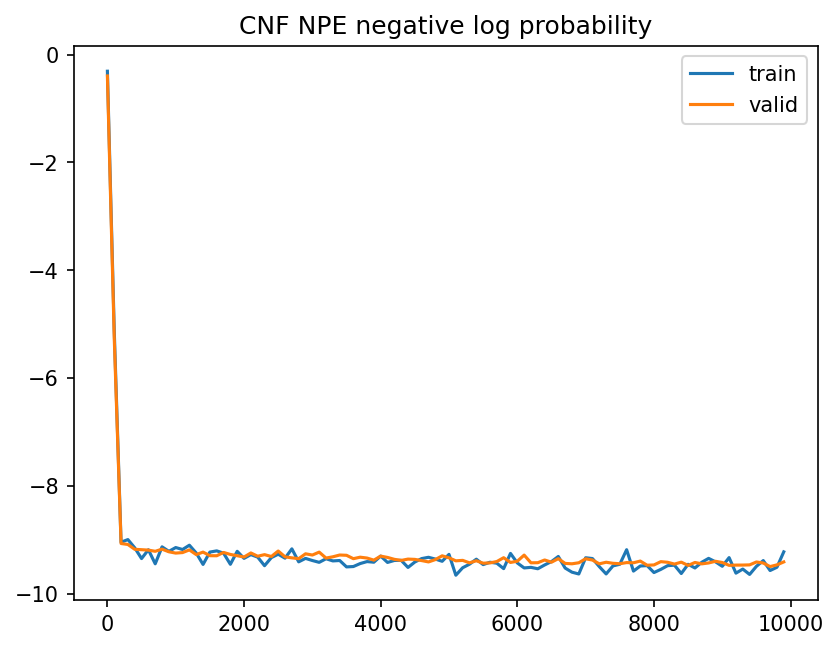

In [21]:
if mlp_losses is not None:
    plt.figure(dpi=150)
    plt.plot(mlp_losses[:, 0], mlp_losses[:, 1], label="train")
    plt.plot(mlp_losses[:, 0], mlp_losses[:, 2], label="valid")
    plt.yscale("log")
    plt.title("MLP compressor MSE")
    plt.legend()
    plt.show()

plt.figure(dpi=150)
plt.plot(cnf_losses[:, 0], cnf_losses[:, 1], label="train")
plt.plot(cnf_losses[:, 0], cnf_losses[:, 2], label="valid")
plt.title("CNF NPE negative log probability")
plt.legend()
plt.show()

## Draw posterior samples and make the ChainConsumer plot

In [22]:
@eqx.filter_jit
def sample_posterior(model, keys, observed_summary):
    return jax.vmap(model.sample_and_log_prob, in_axes=(0, None))(keys, observed_summary)


key, key_sample = jr.split(key)
posterior_samples, posterior_log_probs = sample_posterior(
    cnf, jr.split(key_sample, n_posterior_samples), observed_summary
)

inside_prior = jnp.all((posterior_samples >= lower) & (posterior_samples <= upper), axis=1)
posterior_samples = posterior_samples[inside_prior]
posterior_log_probs = posterior_log_probs[inside_prior]
print(f"kept {posterior_samples.shape[0]} / {n_posterior_samples} samples inside the box prior")

kept 19254 / 20000 samples inside the box prior


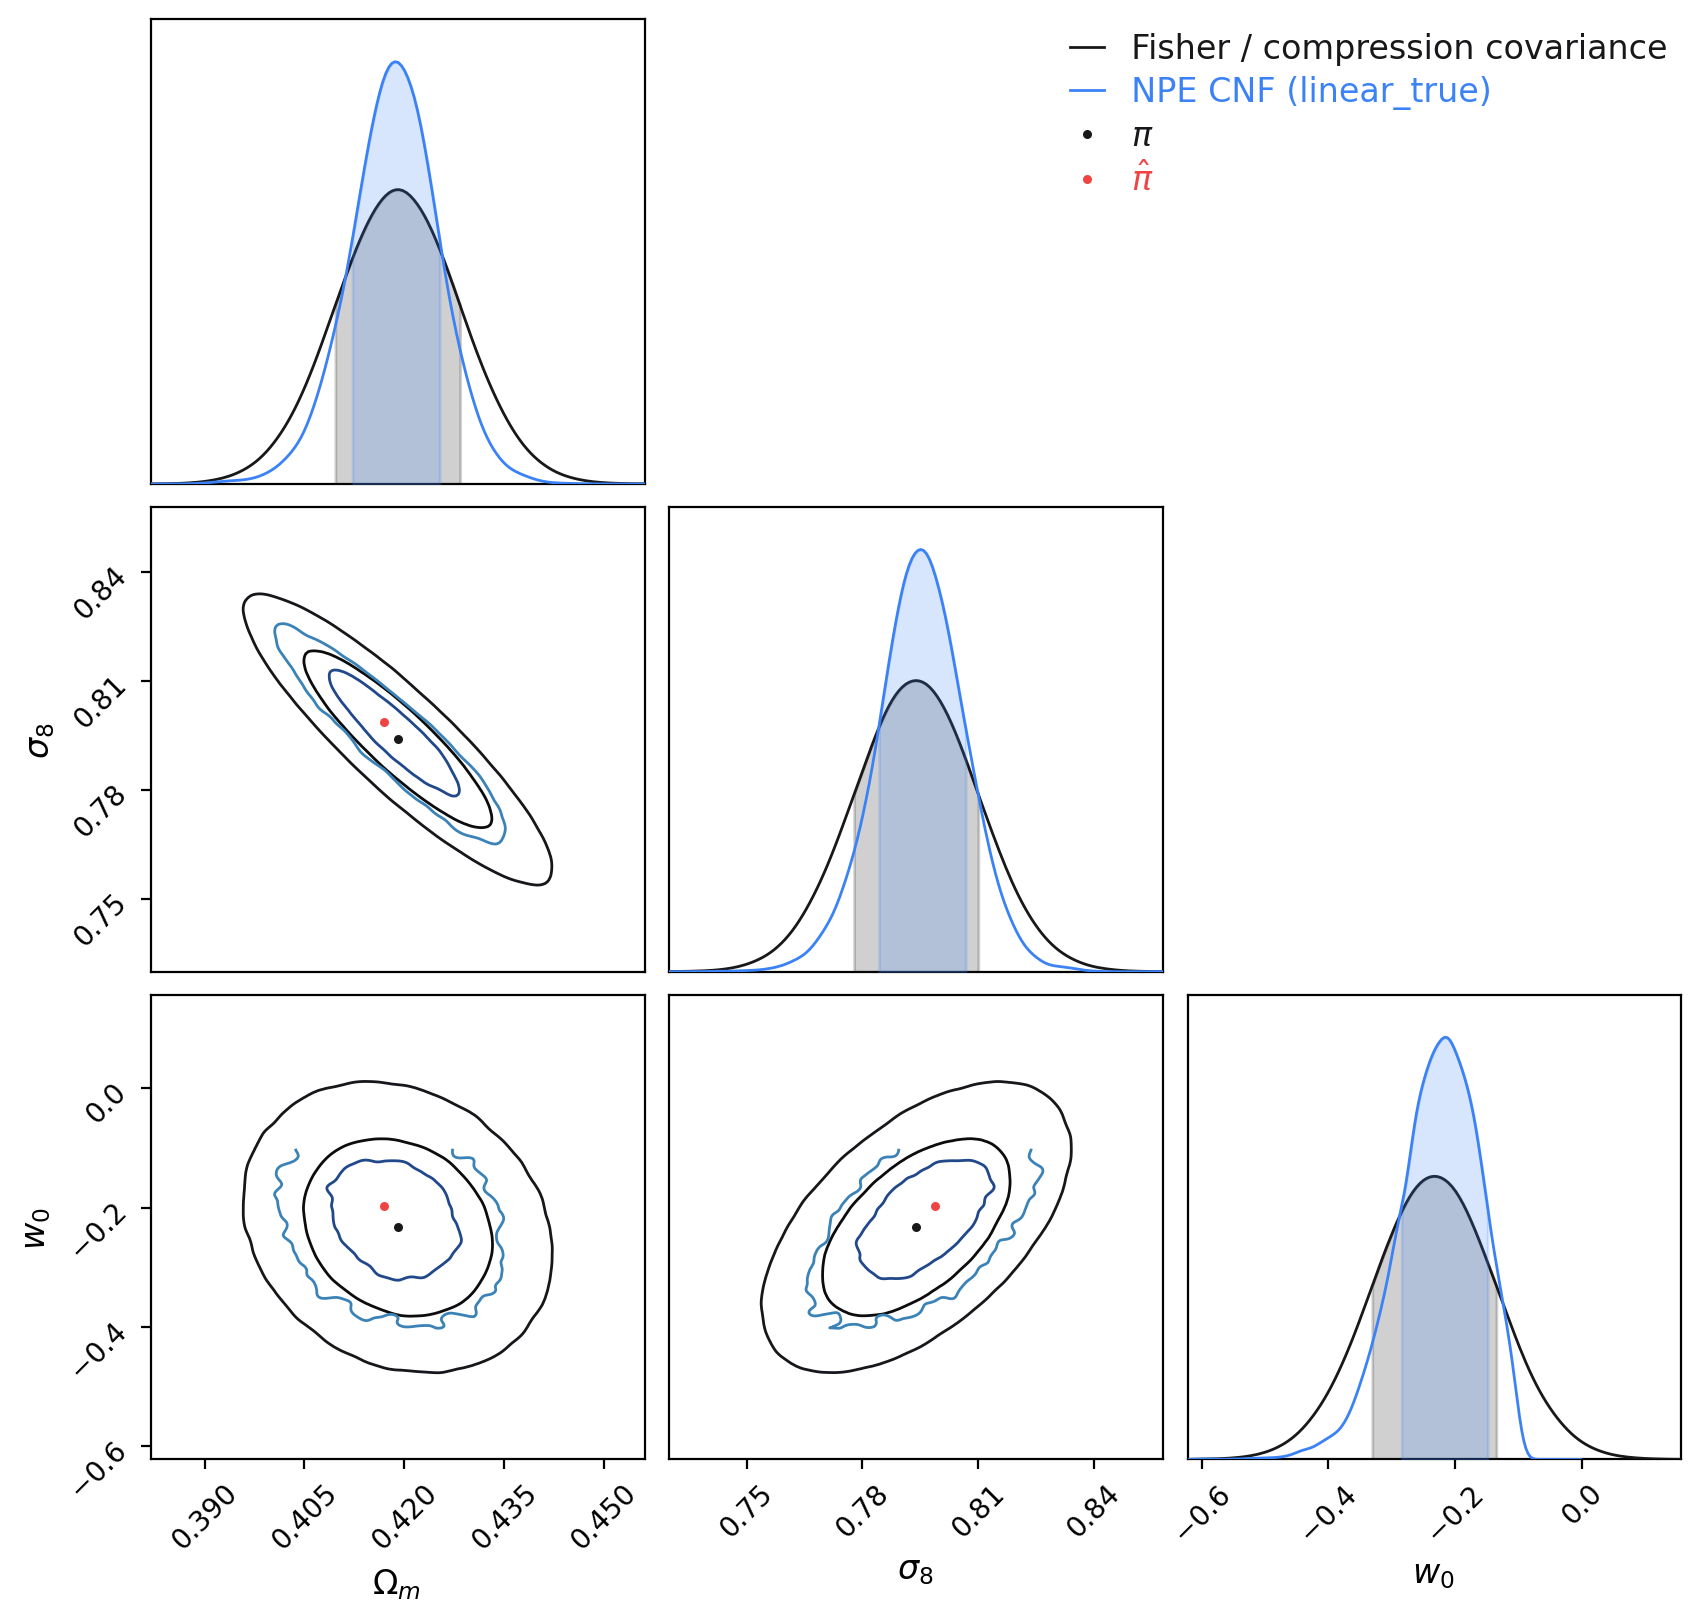

In [23]:
def make_df(samples, log_probs, names):
    return pd.DataFrame(samples, columns=names).assign(log_posterior=log_probs)


plot_cov = 0.5 * (compression_finv_for_plot + compression_finv_for_plot.T)
evals, evecs = jnp.linalg.eigh(plot_cov)
plot_cov = (evecs * jnp.clip(evals, min=1e-12)) @ evecs.T

c = ChainConsumer()
c.add_chain(
    Chain.from_covariance(
        true_parameters,
        plot_cov,
        columns=parameter_names,
        name="Fisher / compression covariance",
        color="k",
        shade_alpha=0.0,
    )
)
c.add_chain(
    Chain(
        samples=make_df(posterior_samples, posterior_log_probs, parameter_names),
        name=f"NPE CNF ({compressor_kind})",
        shade_alpha=0.0,
    )
)
c.add_marker(location=marker(true_parameters, parameter_names), name=r"$\pi$", color="k")
c.add_marker(location=marker(observed_summary, parameter_names), name=r"$\hat{\pi}$", color="r")

fig = c.plotter.plot()
center_triangle_plot(fig, true_parameters, plot_cov)
fig.set_dpi(200)
plt.show()